In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## First Look

In [2]:
df_raw = pd.read_csv("exercise_dataset.csv")
df_raw.head()

,name,target,bodyPart,equipment
0,lever seated hip abduction,abductors,upper legs,leverage machine
1,side hip abduction,abductors,upper legs,body weight
2,straight leg outer hip abductor,abductors,upper legs,body weight
3,side bridge hip abduction,abductors,upper legs,body weight
4,resistance band seated hip abduction,abductors,upper legs,resistance band


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       168 non-null    object
 1   target     168 non-null    object
 2   bodyPart   168 non-null    object
 3   equipment  168 non-null    object
dtypes: object(4)
memory usage: 5.4+ KB


In [5]:
df_raw.isnull().sum()

name         0
target       0
bodyPart     0
equipment    0
dtype: int64

In [6]:
df_raw.columns

Index(['name', 'target', 'bodyPart', 'equipment'], dtype='object')

In [7]:
df_raw["name"].unique()

array(['lever seated hip abduction', 'side hip abduction',
       'straight leg outer hip abductor', 'side bridge hip abduction',
       'resistance band seated hip abduction', '3/4 sit-up',
       '45° side bend', 'air bike', 'alternate heel touchers',
       'assisted hanging knee raise with throw down',
       'assisted hanging knee raise',
       'assisted lying leg raise with lateral throw down',
       'assisted lying leg raise with throw down',
       'assisted motion russian twist', 'barbell press sit-up',
       'cable hip adduction', 'lever seated hip adduction',
       'butterfly yoga pose', 'assisted side lying adductor stretch',
       'side plank hip adduction', 'side lying hip adduction (male)',
       'barbell alternate biceps curl', 'barbell curl',
       'barbell drag curl', 'barbell lying preacher curl',
       'barbell preacher curl', 'barbell prone incline curl',
       'barbell reverse curl', 'barbell reverse preacher curl',
       'barbell seated close-grip conce

In [8]:
df_raw["target"].unique()

array(['abductors', 'abs', 'adductors', 'biceps', 'calves',
       'cardiovascular system', 'delts', 'forearms', 'glutes',
       'hamstrings', 'lats', 'levator scapulae', 'pectorals', 'quads',
       'serratus anterior', 'spine', 'traps', 'triceps', 'upper back'],
      dtype=object)

In [9]:
df_raw["bodyPart"].unique()

array(['upper legs', 'waist', 'upper arms', 'lower legs', 'cardio',
       'shoulders', 'lower arms', 'back', 'neck', 'chest'], dtype=object)

In [10]:
df_raw["equipment"].unique()

array(['leverage machine', 'body weight', 'resistance band', 'assisted',
       'medicine ball', 'barbell', 'cable', 'dumbbell', 'stationary bike',
       'elliptical machine', 'stepmill machine', 'kettlebell',
       'smith machine', 'weighted', 'band', 'stability ball',
       'assisted (towel)'], dtype=object)

## Feature Engineering

In [11]:
compound_keywords = [
    'press', 'squat', 'deadlift', 'row', 'pull-up', 'pullup', 'dip', 'clean', 
    'lunge', 'snatch', 'burpee', 'push-up', 'pushup', 'bench', 'pulldown'
]

isolation_keywords = [
    'curl', 'extension', 'abduction', 'adduction', 'raise', 'fly', 'shrug', 
    'kickback', 'stretch', 'twist', 'rotation', 'bend', 'hyper', 'circle'
]

In [12]:
def determine_exercise_type(name):
    name = name.lower()

    if any(word in name for word in compound_keywords):
        return "Compound"

    elif any(word in name for word in isolation_keywords):
        return "Isolation"

    elif any(word in name for word in ["run", "bike", "walk", "climb", "elliptical"]):
        return "Cardio"
        
    else:
        return "Other"

df_raw["exercise_type"] = df_raw["name"].apply(determine_exercise_type)

In [13]:
df_raw["exercise_type"]

0      Isolation
1      Isolation
2          Other
3      Isolation
4      Isolation
         ...    
163     Compound
164     Compound
165     Compound
166     Compound
167     Compound
Name: exercise_type, Length: 168, dtype: object

In [14]:
def determine_mechanics(name):
    name = name.lower()
    push_words = ["press", "extension", "dip", "squat", "lunge", "push-up", "raise"]
    pull_words = ["row", "curl", "pull-up", "pulldown", "deadlift", "shrug"]
    
    if any(word in name for word in push_words):
        return "Push"
    elif any(word in name for word in pull_words):
        return "Pull"
    else:
        return "Other"

df_raw["mechanics"] = df_raw["name"].apply(determine_mechanics)

In [15]:
df_raw["mechanics"]

0      Other
1      Other
2      Other
3      Other
4      Other
       ...  
163     Pull
164     Pull
165     Pull
166     Pull
167     Pull
Name: mechanics, Length: 168, dtype: object

In [16]:
def estimate_difficulty(row):
    score = 0

    if row["equipment"] in ["barbell", "kettlebell"]:
        score += 2
        
    elif row["equipment"] in ["dumbbell", "cable", "leverage machine"]:
        score += 1
    
    if row["exercise_type"] == "Compound":
        score += 1
        
    return score if score > 0 else 1

df_raw["difficulty_level"] = df_raw.apply(estimate_difficulty, axis=1)

In [17]:
df_raw["difficulty_level"]

0      1
1      1
2      1
3      1
4      1
      ..
163    2
164    2
165    2
166    2
167    2
Name: difficulty_level, Length: 168, dtype: int64

In [18]:
print(df_raw['exercise_type'].value_counts())
print("-" * 30)
print("Others:")
print(df_raw[df_raw['exercise_type'] == 'Other']['name'].unique())

exercise_type
Isolation    73
Compound     68
Other        19
Cardio        8
Name: count, dtype: int64
------------------------------
Others:
['straight leg outer hip abductor' '3/4 sit-up' 'alternate heel touchers'
 'barbell skier' 'dumbbell lying pronation' 'dumbbell lying supination'
 'barbell lying lifting (on hip)' 'assisted prone hamstring'
 'barbell good morning' 'dumbbell lying femoral' 'kick out sit'
 'barbell decline bent arm pullover' 'barbell decline wide-grip pullover'
 'barbell pullover' 'cable incline pushdown' 'cable cross-over variation'
 'balance board' 'incline scapula push up' 'kettlebell sumo high pull']


In [19]:
compound_keywords = [
    "press", "squat", "deadlift", "row", "pull-up", "pullup", "dip", "clean", 
    "lunge", "snatch", "burpee", "push-up", "pushup", "bench", "pulldown",
    "high pull", "lifting", "push up"
]

isolation_keywords = [
    "curl", "extension", "abduction", "adduction", "raise", "fly", "shrug", 
    "kickback", "stretch", "twist", "rotation", "bend", "hyper", "circle",
    "sit-up", "toucher", "abductor", "pronation", "supination", "pullover",
    "good morning", "femoral", "hamstring", "skier", "cross-over", "pushdown"
]
df_raw["exercise_type"] = df_raw["name"].apply(determine_exercise_type)
df_raw["mechanics"] = df_raw["name"].apply(determine_mechanics)
df_raw["difficulty_level"] = df_raw.apply(estimate_difficulty, axis=1)

In [20]:
print(df_raw['exercise_type'].value_counts())
print("-" * 30)
print("Others:")
print(df_raw[df_raw['exercise_type'] == 'Other']['name'].unique())

exercise_type
Isolation    87
Compound     71
Cardio        8
Other         2
Name: count, dtype: int64
------------------------------
Others:
['kick out sit' 'balance board']


In [25]:
df_raw

,name,target,bodyPart,equipment,exercise_type,mechanics,difficulty_level
0,lever seated hip abduction,abductors,upper legs,leverage machine,Isolation,Other,1
1,side hip abduction,abductors,upper legs,body weight,Isolation,Other,1
2,straight leg outer hip abductor,abductors,upper legs,body weight,Isolation,Other,1
3,side bridge hip abduction,abductors,upper legs,body weight,Isolation,Other,1
4,resistance band seated hip abduction,abductors,upper legs,resistance band,Isolation,Other,1
...,...,...,...,...,...,...,...
163,cable floor seated wide-grip row,upper back,back,cable,Compound,Pull,2
164,cable high row (kneeling),upper back,back,cable,Compound,Pull,2
165,cable low seated row,upper back,back,cable,Compound,Pull,2
166,cable one arm bent over row,upper back,back,cable,Compound,Pull,2


## Visualization

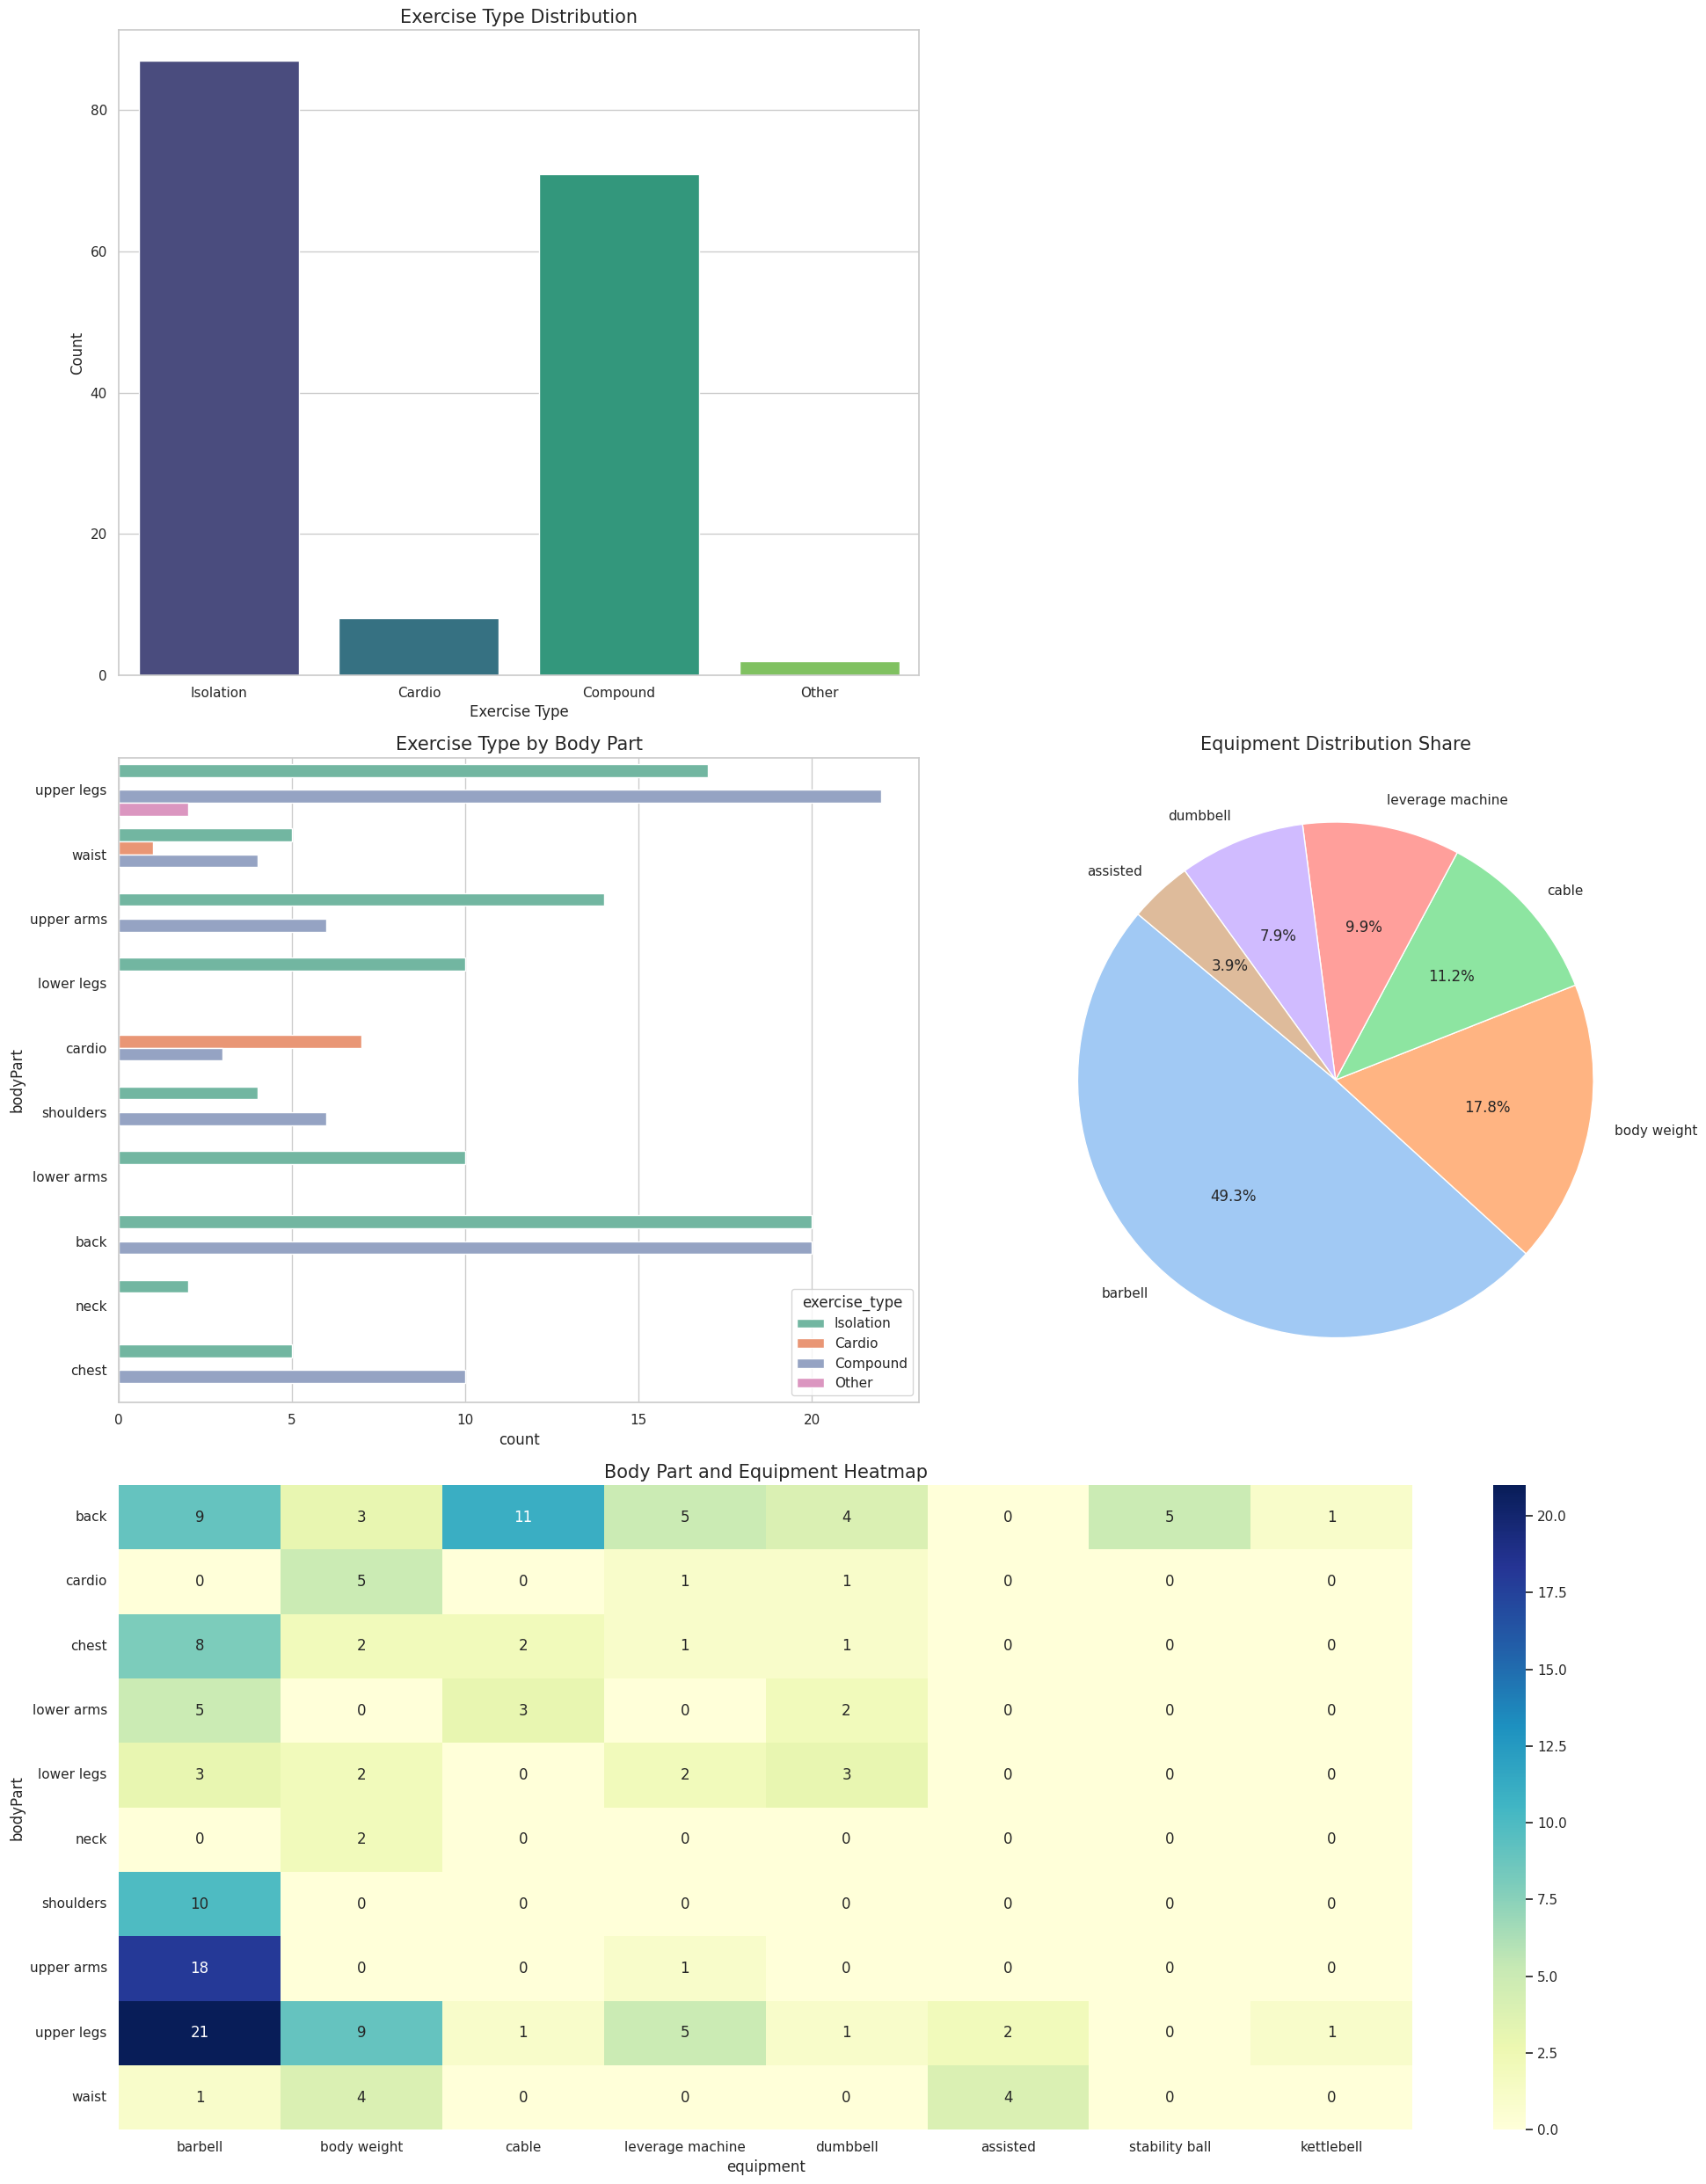

In [21]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 25))

plt.subplot(3, 2, 1)
sns.countplot(data=df_raw, x="exercise_type", palette="viridis")
plt.title("Exercise Type Distribution", fontsize=15)
plt.xlabel("Exercise Type")
plt.ylabel("Count")

plt.subplot(3, 2, 3)
sns.countplot(data=df_raw, y="bodyPart", hue="exercise_type", palette="Set2")
plt.title("Exercise Type by Body Part", fontsize=15)

plt.subplot(3, 2, 4)
equipment_counts = df_raw["equipment"].value_counts().head(6)
plt.pie(equipment_counts, labels=equipment_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Equipment Distribution Share", fontsize=15)

plt.subplot(3, 2, (5, 6))
pivot_table = pd.crosstab(df_raw["bodyPart"], df_raw["equipment"])
top_equip = df_raw["equipment"].value_counts().head(8).index
sns.heatmap(pivot_table[top_equip], annot=True, cmap="YlGnBu", fmt="d")
plt.title("Body Part and Equipment Heatmap", fontsize=15)

plt.tight_layout()
plt.show()

In [26]:
df_raw.to_csv("cleaned_exercises.csv", index=False)